# Weighted Graphs

**Prerequisites**

- Introduction to Graphs
- Strong and Weak Ties

**Outcomes**

- Know what a weighted graph is and how to construct them using `networkx`
- Implement the shortest path algorithm for traversing a weighted graph

**References**

- [Easley and Kleinberg](https://www.cs.cornell.edu/home/kleinber/networks-book/) chapter 5 (especially section 5.1-5-3)

In [1]:
# networkx (and numpy, matplotlib) are already part of the course environment

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Introduction

- So far we have considered a few types of graphs
  - Undirected graph: nodes $A$ and $B$ are connected by an edge 
  - Directed graph: connection from node $A$ to node $B$
  - Strong/weak graphs: each edge is labeled as strong or weak
- Today we extend our understanding of networks to talk about *weighted graphs*
  - Each edge is assigned a `float` denoting the strength of tie
  - Ties can be positive (friends) or negative (enemies)
  - Can also very in strength (+2.0 better friends than +0.2)

### Weighted Adjacency Matrix

- In a simple (unweighted) graph, we used a matrix of 0's and 1's as an adjacency matrix
  - A 1 in row i column j marked an edge between i and j (or from i->j for directed)
  - A 0 marked lack of an edge

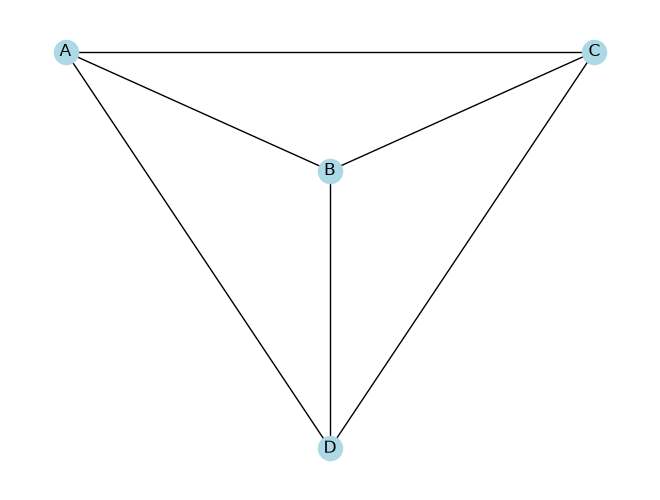

In [3]:
G1 = nx.complete_graph(4)
locs_x = [1, 2, 3, 2.0]
locs_y = [1.0, 0.7, 1, 0]
labels1 = [chr(ord("A") + i) for i in range(G1.number_of_nodes())]
pos1 = {i: (locs_x[i], locs_y[i]) for i in range(G1.number_of_nodes())}

nx.draw(G1, pos1, labels=dict(enumerate(labels1)), with_labels=True, node_color="lightblue")
plt.show()

In [4]:
A1 = nx.to_numpy_array(G1)
A1

array([[0., 1., 1., 1.],
       [1., 0., 1., 1.],
       [1., 1., 0., 1.],
       [1., 1., 1., 0.]])

- We can extend idea of adjacency matrix to include *weighted* edges
- Suppose nodes A, B, C are friends -- but A-C are **best** friends
- Also suppose that all of A, B, C consider D an enemy
- To represent this we might say weight of edges is:
  - `A-B` and `B-C`: 1.0
  - `A-C`: 2.0
  - `A-D`, `B-D`, `C-D`: -1.0
- Here's the adjacency matrix

In [5]:
A2 = np.array([
    [0, 1, 2, -1],
    [1, 0, 1, -1],
    [2, 1, 0, -1],
    [-1, -1, -1, 0.0],
])
A2

array([[ 0.,  1.,  2., -1.],
       [ 1.,  0.,  1., -1.],
       [ 2.,  1.,  0., -1.],
       [-1., -1., -1.,  0.]])

- And here is how we might visualize this graph (notice the labeled edges)

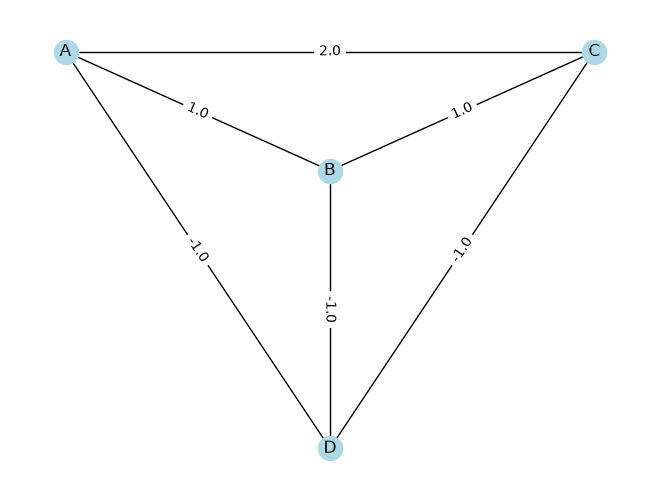

In [6]:
G2 = nx.from_numpy_array(A2)
edge_labels2 = nx.get_edge_attributes(G2, "weight")

nx.draw(G2, pos1, labels=dict(enumerate(labels1)), with_labels=True, node_color="lightblue")
nx.draw_networkx_edge_labels(G2, pos1, edge_labels=edge_labels2)
plt.show()

## Shortest Paths

- We talked previously about shortest paths for a Graph
- This was defined as the minimum number of edges needed to move from node n1 to node n2
- When we have a weighted graph things get more interesting...
- Let $w_{ab}$ represent the weight connecting nodes $A$ and $B$
- Define the shortest path between n1 and n2 as the path that minimizes $\sum w_{ab}$ for all edges `A->B` along a path

### Example

- Consider the following directed graph

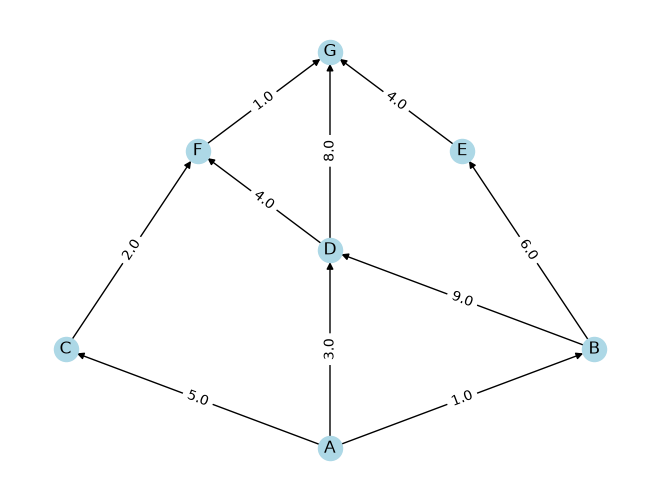

In [7]:
A3 = np.array([
    [0, 1, 5, 3, 0, 0, 0],
    [0, 0, 0, 9, 6, 0, 0],
    [0, 0, 0, 0, 0, 2, 0],
    [0, 0, 0, 0, 0, 4, 8],
    [0, 0, 0, 0, 0, 0, 4],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
], dtype=float)
G3 = nx.from_numpy_array(A3, create_using=nx.DiGraph)

# plotting details
locs_x_3 = [3, 5, 1, 3, 4, 2, 3.0]
locs_y_3 = [1, 2, 2, 3, 4, 4, 5.0]
labels3 = [chr(ord("A") + i) for i in range(A3.shape[0])]
pos3 = {i: (locs_x_3[i], locs_y_3[i]) for i in range(A3.shape[0])}
edge_labels3 = nx.get_edge_attributes(G3, "weight")

nx.draw(G3, pos3, labels=dict(enumerate(labels3)), with_labels=True, node_color="lightblue", arrows=True)
nx.draw_networkx_edge_labels(G3, pos3, edge_labels=edge_labels3)
plt.show()

- We wish to travel from node A to node G at minimum cost
- The shortest path (ignoring weights)  is A-D-G
- Taking into account weights we have 3 + 8 = 11
- There are two other paths that lead to lower cost (total of 8)
  - `A-C-F-G` has cost 5 + 2 + 1 = 8
  - `A-D-F-G` has cost 3 + 4 + 1 = 8
- For this small graph, we could find these paths by hand
- For a larger one, we will need an algorithm...

### Shortest path algorithm

- Let $J(v)$ be the minimum cost-to-go from node $v$ to node G
- Suppose that we know $J(v)$ for each node $v$, as shown below for our example graph
  - Note $J(G) = 0$

![https://compsosci-resources.s3.amazonaws.com/graph-theory-lectures/images/graph_costs.png](https://compsosci-resources.s3.amazonaws.com/graph-theory-lectures/images/graph_costs.png)

- With $J(v)$ in hand, the following algorithm will find the cost-minimizing path from $A$ to $G$:
  1. Start with $v = A$
  2. From current node $v$ move to any node that solves $\min_{n \in F_v} w_{vn} + J(n)$, where $F_v$ is the set of nodes that can be reached from $v$. 
  3. Update notation to set $v = n$
  3. Repeat steps 2-3 (making note of which we visit) until $v = G$

### Exercise: Traversing Cost-Minimizing Path

- Let's implement the algorithm above
- Below I have started a function called `traverse_graph`
- Your task is to complete it until you get that the minimum cost path has a cost of 8 and length(4)

In [8]:
J3 = np.array([8, 10, 3, 5, 4, 1, 0])

In [9]:
def traverse_graph(G, J, start_node, end_node):
    path = [start_node]
    cost = 0.0
    W = nx.to_numpy_array(G)

    # TODO: step 1, initialize v
    v = 0  # CHANGE ME
    num = 0
    while v != end_node and num < G.number_of_nodes():  # prevent infinite loop
        num += 1
        F_v = list(G.neighbors(v))

        # TODO: step 2, compute costs for all n in F_v
        costs = [0 for n in F_v]  # CHANGE ME

        n = F_v[np.argmin(costs)]

        # TODO: how should we update cost?
        cost += 0  # CHANGE ME

        path.append(n)

        # TODO: step 3 -- update v
        v = v  # CHANGE ME

    return path, cost

In [10]:
traverse_graph(G3, J3, 0, 6)

([0, 1, 1, 1, 1, 1, 1, 1], 0.0)

### But what about $J(v)$

- The shortest path algorithm we presented above sounds simple, but assumed we know $J(v)$ 
- How can we find it?
- If you stare at the following equation long enough, you'll be convinced that $J$ satisfies
$$J(v) = \min_{n \in F_v} w_{vn} + J(n)$$
- This is known as the *Bellman equation*
- It is a restriction that $J$ must satisfy
- We'll use this restriction to compute $J$

### Computing J: Guess and Iterate

- We'll present the standard algorithm for computing $J(v)$
- This is an iterative method
- Let $i$ represent the iteration we are on and $J_i(v)$ be the guess for $J(v)$ on iteration $i$
- Algorithm
  1. Set $i=0$, and $J_i(v) = 0 \forall v$
  2. Set $J_{i+1}(v) = \min_{n \in F_v} w_{vn} + J_i(n) \forall n$
  3. Check if $J_{i+1}$ and $J_i$ are equal for all $v$ -- if not set $i = i+1$ and see repeat steps 2-3
- This algorithm converges to $J$ (we won't prove it here...)

### Implementation

- Let's now implement the algorithm!
- We'll walk you through our implementation

In [11]:
def cost(W, J, n, v):
    return W[v, n] + J[n]

In [12]:
def compute_J(G, dest_node):
    N = G.number_of_nodes()
    # step 1. start with zeros
    i = 0
    Ji = np.zeros(N)

    next_J = np.zeros(N)

    W = nx.to_numpy_array(G)

    done = False
    while not done:
        i += 1
        for v in range(N):
            if v == dest_node:
                next_J[v] = 0
                continue
            F_v = list(G.neighbors(v))
            costs = [cost(W, Ji, n, v) for n in F_v]
            next_J[v] = min(costs)
        done = np.allclose(next_J, Ji)
        Ji = next_J.copy()
    return Ji

In [13]:
compute_J(G3, 6)

array([ 8., 10.,  3.,  5.,  4.,  1.,  0.])

## Exercise: Shortest Path

- Let's now combine the two functions to compute a shortest path (and associated cost) for a graph
- Your task is to fill in the function below and get the test to pass

In [14]:
def shortest_path(G, start_node, end_node):
    """Given a weighted graph `G`, enumerate a shortest path between `start_node` and `end_node`."""
    # your code here

## Summary

- Weighted graphs allow us to analyze the cost of travsersing paths
    - Applied in situations like traffic flows (on physical roads/bridges), resource planning, supply chain, international trade (weights as tarrifs), and more
- Programming skills...
    - We built up an algorithm `shortest_path` using two smaller routines: `traverse_graph`, `compute_J`
    - For each of the 3 functions we were able to write tests to verify code correctness
    - Good habit to break a hard problem into smaller sub-problems that can be implemented/tested separately
    - Then compose overall routine using functions for sub-problems
    - Not all practitioners do this... we've seen some *scary* notebooks and scripts... don't do that... you know better